In [1]:
import numpy as np
import os
import sys

import wave
import copy
import math

from keras.models import Sequential, Model
from keras.layers import Dense, Activation
from keras.layers import LSTM, Input, Flatten, Concatenate, Embedding, Convolution1D,Dropout
from keras.layers import TimeDistributed
from keras.optimizers import SGD, Adam, RMSprop
from keras.layers import BatchNormalization
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.preprocessing import sequence

from pathlib import Path

# Define the path to the helper files
helperfiles_path = Path('C:/Users/91984/Desktop/project work')

# Import your modules
import sys
sys.path.append(str(helperfiles_path))

from features import *
from helper import *




In [2]:
code_path = os.path.dirname(os.path.realpath(os.getcwd()))
emotions_used = np.array(['ang', 'exc', 'neu', 'sad'])
data_path = code_path + "/../data/sessions/"
sessions = ['Session1', 'Session2', 'Session3', 'Session4', 'Session5']
framerate = 16000

In [3]:
import pickle

data_path = 'C:/Users/91984/Desktop/project work/data_collected_full.pickle'

with open(data_path, 'rb') as handle:
    data2 = pickle.load(handle)


In [4]:
def calculate_features(frames, freq, options):
    window_sec = 0.2
    window_n = int(freq * window_sec)

    st_f = stFeatureExtraction(frames, freq, window_n, window_n / 2)

    if st_f.shape[1] > 2:
        i0 = 1
        i1 = st_f.shape[1] - 1
        if i1 - i0 < 1:
            i1 = i0 + 1
        
        deriv_st_f = np.zeros((st_f.shape[0], i1 - i0), dtype=float)
        for i in range(i0, i1):
            i_left = i - 1
            i_right = i + 1
            deriv_st_f[:st_f.shape[0], i - i0] = st_f[:, i]
        return deriv_st_f
    elif st_f.shape[1] == 2:
        deriv_st_f = np.zeros((st_f.shape[0], 1), dtype=float)
        deriv_st_f[:st_f.shape[0], 0] = st_f[:, 0]
        return deriv_st_f
    else:
        deriv_st_f = np.zeros((st_f.shape[0], 1), dtype=float)
        deriv_st_f[:st_f.shape[0], 0] = st_f[:, 0]
        return deriv_st_f

In [5]:
x_train_speech = []

counter = 0
for ses_mod in data2:
    x_head = ses_mod['signal']
    st_features = calculate_features(x_head, framerate, None)
    st_features, _ = pad_sequence_into_array(st_features, maxlen=100)
    x_train_speech.append( st_features.T )
    counter+=1
    if(counter%100==0):
        print(counter)
    
x_train_speech = np.array(x_train_speech)
x_train_speech.shape

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900


(4936, 100, 34)

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from keras import regularizers
# Capsule Layer Definition (as previously explained)
class CapsuleLayer(layers.Layer):
    def __init__(self, num_capsules, dim_capsule, routings=3, **kwargs):
        super(CapsuleLayer, self).__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.kernel = self.add_weight(shape=(input_shape[-1], self.num_capsules * self.dim_capsule),
                                      initializer='glorot_uniform',
                                      trainable=True)

    def call(self, inputs):
        inputs = tf.expand_dims(inputs, axis=2)
        inputs_hat = tf.matmul(inputs, self.kernel)
        inputs_hat = tf.reshape(inputs_hat, (-1, inputs.shape[1], self.num_capsules, self.dim_capsule))

        b = tf.zeros(shape=[tf.shape(inputs_hat)[0], inputs.shape[1], self.num_capsules])

        for i in range(self.routings):
            c = tf.nn.softmax(b, axis=-1)
            outputs = tf.reduce_sum(c[..., tf.newaxis] * inputs_hat, axis=1)
            outputs = self.squash(outputs)

            if i < self.routings - 1:
                b += tf.reduce_sum(inputs_hat * outputs[:, tf.newaxis, :, :], axis=-1)

        return outputs

    def squash(self, vectors, axis=-1):
        s_squared_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
        scale = s_squared_norm / (1 + s_squared_norm) / tf.sqrt(s_squared_norm + tf.keras.backend.epsilon())
        return scale * vectors

# Capsule Network Model for Speech Features
def AttentionCapsuleModel(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # First convolutional layer (using Conv1D)
    x = layers.Conv1D(32, kernel_size=3, activation='relu')(inputs)  # Adjust the filters and kernel size as needed
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Capsule layer
    capsule_output = CapsuleLayer(num_capsules=10, dim_capsule=16)(x)  # Example parameters, implement CapsuleLayer correctly

    # Attention mechanism (applying attention to the capsule output)
    attention_output = layers.Attention()([capsule_output, capsule_output])

    # Flattening the output and adding fully connected layers
    x = layers.Flatten()(attention_output)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model


In [7]:
from sklearn.preprocessing import label_binarize

y_train = []
for ses_mod in data2:
    y_train.append(ses_mod['emotion'])

# Check what emotions_used is
print("Emotions used:", emotions_used)

# Use label_binarize correctly
y_train = label_binarize(y_train, classes=emotions_used)

# Check the shape of Y
print("Shape of y_train:", y_train.shape)

Emotions used: ['ang' 'exc' 'neu' 'sad']
Shape of y_train: (4936, 4)


In [8]:
xtrain_sp = x_train_speech[:3838]
xtest_sp = x_train_speech[3838:]
ytrain_sp = y_train[:3838]
ytest_sp = y_train[3838:]

In [9]:
print("Shape of xtest_sp:", xtest_sp.shape)  # Should be (num_samples, time_steps, num_features)
print("Shape of ytest_sp:", ytest_sp.shape)  # Should be (num_samples, num_classes) if using categorical

Shape of xtest_sp: (1098, 100, 34)
Shape of ytest_sp: (1098, 4)


In [10]:
# Input shape for speech features (adjust based on your actual data)
from keras.callbacks import EarlyStopping
input_shape = x_train_speech.shape[1:]  # (time_steps, num_features)
num_classes = 4  # Number of emotion classes in IEMOCAP

model = AttentionCapsuleModel(input_shape, num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Train the model
history = model.fit(x_train_speech, y_train, epochs=100, batch_size=32, validation_split=0.2)



Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.3310 - loss: 2.2352 - val_accuracy: 0.4150 - val_loss: 1.3797
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4251 - loss: 1.2983 - val_accuracy: 0.4960 - val_loss: 1.2011
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4542 - loss: 1.1942 - val_accuracy: 0.4747 - val_loss: 1.1903
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4648 - loss: 1.1682 - val_accuracy: 0.4818 - val_loss: 1.1793
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4746 - loss: 1.1430 - val_accuracy: 0.4291 - val_loss: 1.2271
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4725 - loss: 1.1403 - val_accuracy: 0.5192 - val_loss: 1.1292
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5002 - loss: 1.1144 - val_accuracy: 0.5152 - val_loss: 1.1246
Epoch 8/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4951 - loss: 1.1311 

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GRU, Dense, Dropout, Flatten, MultiHeadAttention, Input
from tensorflow.keras.optimizers import Adam

def create_model(input_shape):
    inputs = Input(shape=input_shape)
    
    # Convolutional layers for feature extraction
    x = Conv1D(filters=64, kernel_size=3, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Conv1D(filters=128, kernel_size=3, activation='relu')(x)
    x = Dropout(0.2)(x)

    # MultiHeadAttention layer
    attention_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)

    # GRU Layers
    x = GRU(units=64, return_sequences=True)(attention_output)
    x = GRU(units=32)(x)
    
    # Fully connected output layer
    outputs = Dense(y_train.shape[1], activation='softmax')(x)  # Assuming 4 classes for emotions

    # Create model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [12]:
print(x_train_speech.shape)

(4936, 100, 34)


In [13]:
model2 = create_model((100, 34))
model2.summary()

# Train the model
history = model2.fit(x_train_speech, y_train, validation_data=(xtest_sp, ytest_sp), epochs=65, batch_size=32)




Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 34)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 98, 64)    │      6,592 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 98, 64)    │          0 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 96, 128)   │     24,704 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 96, 128)   │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 128)   │    131,968 │ dropout_2[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 96, 64)    │     37,248 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 32)        │      9,408 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 4)         │        132 │ gru_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 210,052 (820.52 KB)

 Trainable params: 210,052 (820.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 28s 141ms/step - accuracy: 0.3864 - loss: 1.3038 - val_accuracy: 0.4362 - val_loss: 1.1904
Epoch 2/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 22s 144ms/step - accuracy: 0.4625 - loss: 1.1545 - val_accuracy: 0.4763 - val_loss: 1.1590
Epoch 3/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - accuracy: 0.4911 - loss: 1.1156 - val_accuracy: 0.4208 - val_loss: 1.1950
Epoch 4/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - accuracy: 0.4925 - loss: 1.1036 - val_accuracy: 0.4872 - val_loss: 1.1674
Epoch 5/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.5175 - loss: 1.0945 - val_accuracy: 0.4709 - val_loss: 1.1559
Epoch 6/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 32s 206ms/step - accuracy: 0.4932 - loss: 1.0971 - val_accuracy: 0.5128 - val_loss: 1.0724
Epoch 7/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.4940 - loss: 1.0728 - val_accuracy: 0.5082 - val_loss: 1.0755
Epoch 8/65
155/155 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.5054 - loss: 1

In [14]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 34)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 98, 32)    │      3,296 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 49, 32)    │          0 │ conv1d[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capsule_layer       │ (None, 10, 16)    │      5,120 │ max_pooling1d[0]… │
│ (CapsuleLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 10, 16)    │          0 │ capsule_layer[0]… │
│ (Attention)         │                   │            │ capsule_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 160)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     20,608 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        516 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 88,622 (346.18 KB)

 Trainable params: 29,540 (115.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 59,082 (230.79 KB)

In [15]:
# Evaluate the model
test_loss, test_acc = model.evaluate(xtest_sp, ytest_sp)
print('Test accuracy:', test_acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5584 - loss: 1.0609
Test accuracy: 0.5264116525650024


In [16]:
# Evaluate the model
test_loss2, test_acc2 = model2.evaluate(xtest_sp, ytest_sp)
print('Test accuracy:', test_acc2)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8116 - loss: 0.5178
Test accuracy: 0.817850649356842


In [18]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
def plot_training_history(history):
    # Plot training & validation accuracy
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first plot
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second plot
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()


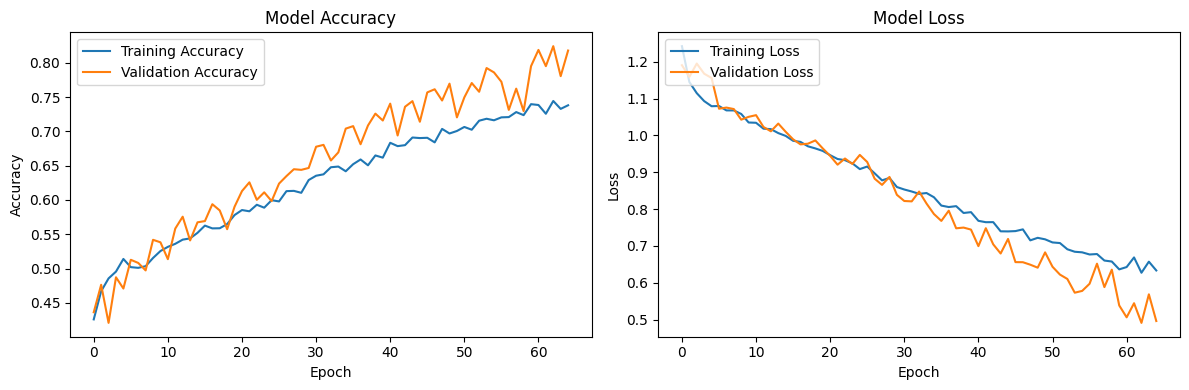

In [19]:
# Call the function to plot the training history
plot_training_history(history)

In [23]:
y_pred=model2.predict(xtest_sp)
y_pred_classes = y_pred.argmax(axis=1)
y_true = ytest_sp.argmax(axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


In [24]:
from sklearn.metrics import classification_report

# Classification report
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82       170
           1       0.83      0.79      0.81       299
           2       0.77      0.87      0.82       384
           3       0.86      0.79      0.82       245

    accuracy                           0.82      1098
   macro avg       0.83      0.81      0.82      1098
weighted avg       0.82      0.82      0.82      1098



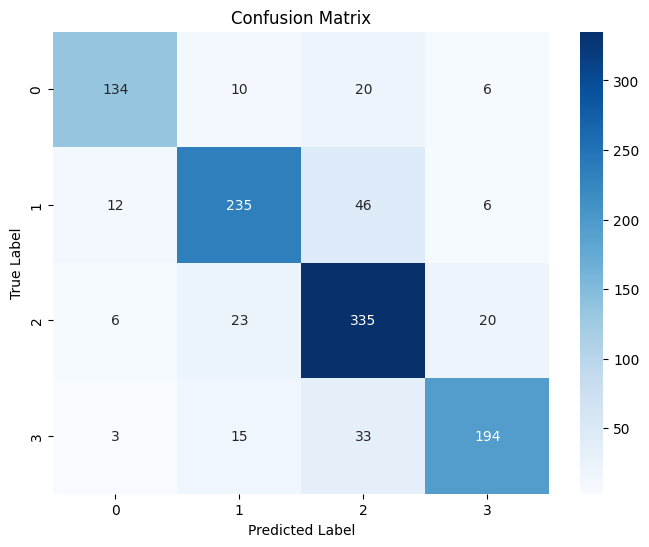

In [26]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [33]:
# Save the model to a specific location
model.save('C:/Users/91984/Desktop/project_model/model2.h5')  


In [32]:
# Save the model to a specific location
model.save('C:/Users/91984/Desktop/project_model/model2.keras')  
